In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

In [4]:
columns = [
    'class','cap-shape','cap-surface','cap-color','bruises','odor',
    'gill-attachment','gill-spacing','gill-size','gill-color',
    'stalk-shape','stalk-root','stalk-surface-above-ring',
    'stalk-surface-below-ring','stalk-color-above-ring',
    'stalk-color-below-ring','veil-type','veil-color',
    'ring-number','ring-type','spore-print-color',
    'population','habitat']

df = pd.read_csv(r"C:\Users\Merutha sree\Downloads\mushroom (1)\agaricus-lepiota.data", names=columns)

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
df.shape
df.describe

<bound method NDFrame.describe of      class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0        p         x           s         n       t    p               f   
1        e         x           s         y       t    a               f   
2        e         b           s         w       t    l               f   
3        p         x           y         w       t    p               f   
4        e         x           s         g       f    n               f   
...    ...       ...         ...       ...     ...  ...             ...   
8119     e         k           s         n       f    n               a   
8120     e         x           s         n       f    n               a   
8121     e         f           s         n       f    n               a   
8122     p         k           y         n       f    y               f   
8123     e         x           s         n       f    n               a   

     gill-spacing gill-size gill-color  ... stalk-surface-below-r

In [6]:
df.columns = columns

In [9]:
df.to_csv("mushroom_cleaned.csv", index=False)
df = pd.read_csv("mushroom_cleaned.csv")


In [7]:
import os
print(os.getcwd())

c:\Users\Merutha sree\OneDrive\Desktop\python_ml


In [9]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

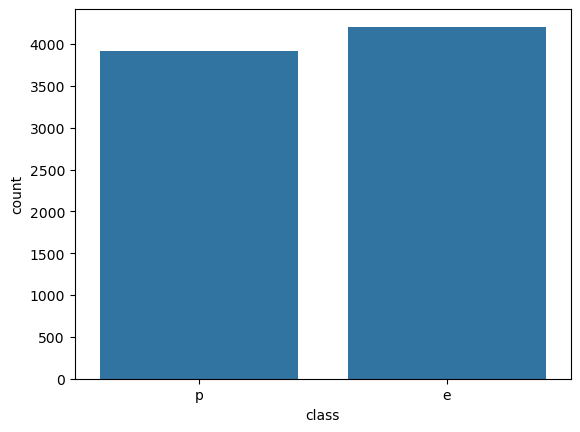

In [10]:
sns.countplot(x='class', data=df)
plt.show()

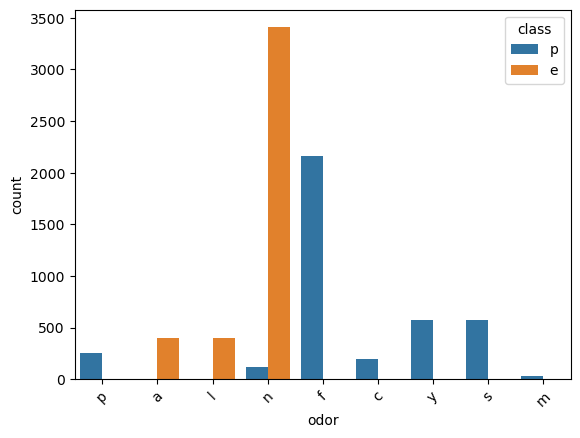

In [11]:
sns.countplot(x='odor', hue='class', data=df)
plt.xticks(rotation=45)
plt.show()

In [ ]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("class", axis=1)
y = df["class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [14]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)
classification_report(y_test, y_pred)
confusion_matrix(y_test, y_pred)

array([[843,   0],
       [  0, 782]])

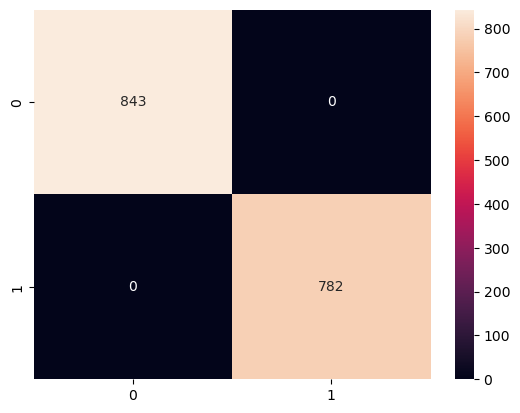

In [15]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.show()

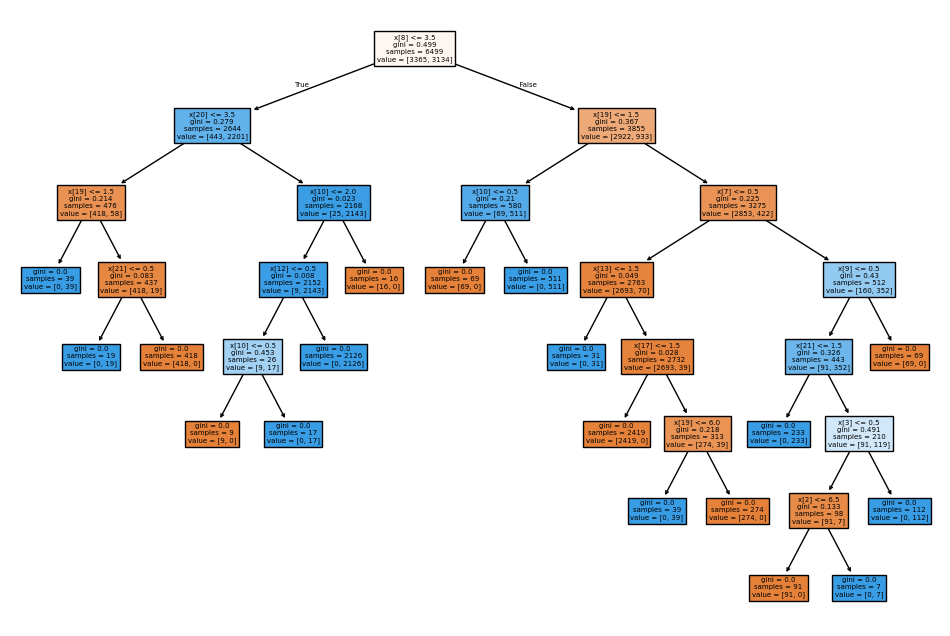

In [16]:
plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()

In [18]:
params = {
    'max_depth': [3,5,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}
grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train, y_train)
grid.best_params_



{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}

In [19]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [21]:
cv_score = cross_val_score(best_model, X, y, cv=5)

print("CV Accuracy:", cv_score.mean())

CV Accuracy: 0.9093758241758243
